In [ ]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")

print("Path to dataset files:", path)

100%|██████████| 12.3G/12.3G [05:35<00:00, 39.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1


# MambaBTS — Brain Tumor Segmentation on BraTS 2021
**Dataset:** `dschettler8845/brats-2021-task1`

Attach the dataset in Kaggle settings before running:
- `BraTS2021_Training_Data.tar` (full training set)
- `BraTS2021_00495.tar` / `BraTS2021_00621.tar` (held-out test subjects)

Enable GPU accelerator: *Settings → Accelerator → GPU T4 x2* (or P100).

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
print("Files in input directory:")
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1'):
    print(dirname)
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Files in input directory:
/root/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1
/root/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1/BraTS2021_00621.tar
/root/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1/BraTS2021_Training_Data.tar
/root/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1/BraTS2021_00495.tar


## 0. Install dependencies

In [ ]:
%%capture
!pip install nibabel scipy scikit-learn --quiet
# antspyx is optional (N4 bias correction) — large wheel, skip if slow
# !pip install antspyx --quiet

## 1. Extract BraTS 2021 archives

In [8]:
import os, tarfile, glob

INPUT_DIR  = '/root/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1'
WORK_DIR   = "/kaggle/working"
DATA_DIR   = os.path.join(WORK_DIR, "brats2021")
TEST_DIR   = os.path.join(WORK_DIR, "brats2021_test")
CKPT_DIR   = os.path.join(WORK_DIR, "checkpoints")

os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(TEST_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR,  exist_ok=True)

# ── Extract main training archive ────────────────────────────────────────────
train_tar = os.path.join(INPUT_DIR, "BraTS2021_Training_Data.tar")
if os.path.exists(train_tar):
    print(f"Extracting {train_tar} ...")
    with tarfile.open(train_tar, "r") as tf:
        tf.extractall(DATA_DIR)
    print("Done.")
else:
    print(f"WARNING: {train_tar} not found — check dataset attachment.")

# ── Extract held-out test subjects ───────────────────────────────────────────
for fname in ["BraTS2021_00495.tar", "BraTS2021_00621.tar"]:
    fpath = os.path.join(INPUT_DIR, fname)
    if os.path.exists(fpath):
        print(f"Extracting {fname} ...")
        with tarfile.open(fpath, "r") as tf:
            tf.extractall(TEST_DIR)
        print("Done.")
    else:
        print(f"WARNING: {fpath} not found.")

# ── Verify dataset structure ──────────────────────────────────────────────────
subjects = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
print(f"\nFound {len(subjects)} training subjects.")
if subjects:
    print("First subject files:")
    first = os.path.join(DATA_DIR, subjects[0])
    for f in sorted(os.listdir(first)):
        print(f"  {f}")

Extracting /root/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1/BraTS2021_Training_Data.tar ...


/tmp/ipykernel_344922/2279599381.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(DATA_DIR)


Done.
Extracting BraTS2021_00495.tar ...
Done.
Extracting BraTS2021_00621.tar ...
Done.

Found 1251 training subjects.
First subject files:
  BraTS2021_00000_flair.nii.gz
  BraTS2021_00000_seg.nii.gz
  BraTS2021_00000_t1.nii.gz
  BraTS2021_00000_t1ce.nii.gz
  BraTS2021_00000_t2.nii.gz


/tmp/ipykernel_344922/2279599381.py:29: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(TEST_DIR)


## 2. Normalise directory layout

BraTS 2021 files use the naming convention:
`BraTS2021_XXXXX_t1.nii.gz`, `_t1ce.nii.gz`, `_t2.nii.gz`, `_flair.nii.gz`, `_seg.nii.gz`

The `BraTSDataset` loader in `mamba_bts_impl.py` expects exactly this layout — no action required.
The cell below validates a sample subject to confirm.

In [ ]:
import nibabel as nib

MODALITIES = ["t1", "t1ce", "t2", "flair"]

def check_subject(subj_dir: str):
    name = os.path.basename(subj_dir)
    ok = True
    for mod in MODALITIES + ["seg"]:
        p = os.path.join(subj_dir, f"{name}_{mod}.nii.gz")
        if not os.path.exists(p):
            print(f"  MISSING: {p}")
            ok = False
    if ok:
        img = nib.load(os.path.join(subj_dir, f"{name}_t1.nii.gz"))
        print(f"  {name}: shape={img.shape}, voxel size={img.header.get_zooms()}")

if subjects:
    print("Checking first 3 subjects:")
    for s in subjects[:3]:
        check_subject(os.path.join(DATA_DIR, s))

test_subjects = sorted([
    d for d in os.listdir(TEST_DIR)
    if os.path.isdir(os.path.join(TEST_DIR, d))
])
print(f"\nTest subjects ({len(test_subjects)}):")
for s in test_subjects:
    check_subject(os.path.join(TEST_DIR, s))

Checking first 3 subjects:
  BraTS2021_00000: shape=(240, 240, 155), voxel size=(np.float32(1.0), np.float32(1.0), np.float32(1.0))
  BraTS2021_00002: shape=(240, 240, 155), voxel size=(np.float32(1.0), np.float32(1.0), np.float32(1.0))
  BraTS2021_00003: shape=(240, 240, 155), voxel size=(np.float32(1.0), np.float32(1.0), np.float32(1.0))

Test subjects (0):


## 2.5 Visualise random samples from training set

Sampled subjects: ['BraTS2021_00543', 'BraTS2021_00003', 'BraTS2021_01236']


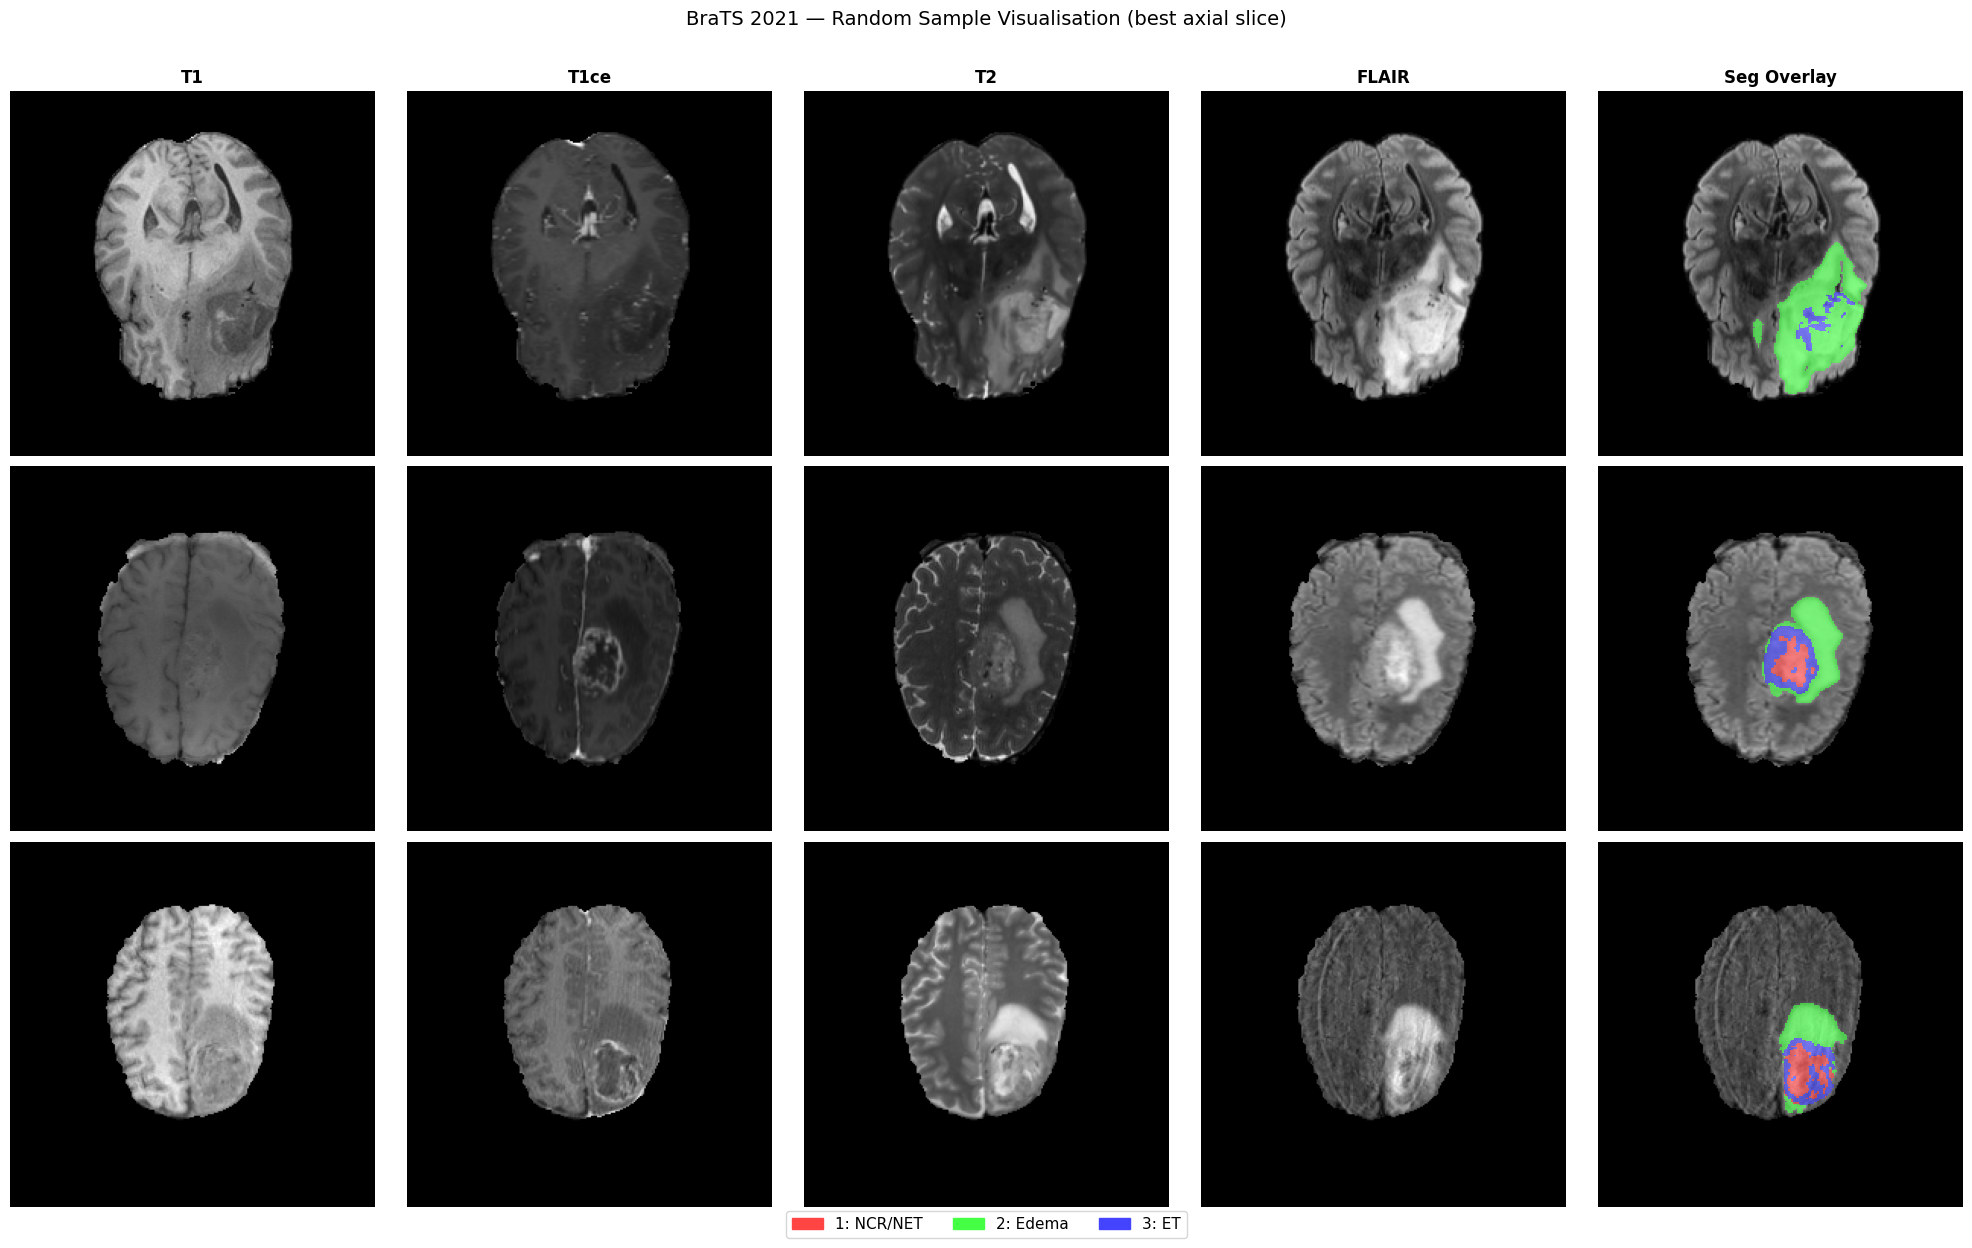

In [ ]:
import random
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ── Config ────────────────────────────────────────────────────────────────────
N_SAMPLES    = 3          # จำนวน subject ที่จะสุ่ม
MODALITIES   = ["t1", "t1ce", "t2", "flair"]
MOD_TITLES   = ["T1", "T1ce", "T2", "FLAIR"]
LABEL_INFO   = {
    1: ("NCR/NET", "#FF4444"),
    2: ("Edema",   "#44FF44"),
    3: ("ET",      "#4444FF"),
}

# ── ฟังก์ชัน helper ───────────────────────────────────────────────────────────
def load_subject(subj_dir: str, subj_name: str):
    """โหลด 4 modalities + seg; คืนค่า dict ของ numpy arrays"""
    data = {}
    for mod in MODALITIES:
        p = os.path.join(subj_dir, f"{subj_name}_{mod}.nii.gz")
        data[mod] = nib.load(p).get_fdata(dtype=np.float32)
    seg_path = os.path.join(subj_dir, f"{subj_name}_seg.nii.gz")
    if os.path.exists(seg_path):
        seg = nib.load(seg_path).get_fdata(dtype=np.float32).astype(np.uint8)
        seg[seg == 4] = 3   # remap BraTS label 4 → 3
    else:
        seg = None
    return data, seg

def best_axial_slice(seg: np.ndarray) -> int:
    """หา axial slice ที่มี tumour voxel เยอะที่สุด"""
    if seg is None:
        return seg.shape[2] // 2
    counts = [(seg[:, :, z] > 0).sum() for z in range(seg.shape[2])]
    return int(np.argmax(counts))

def norm(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-8)

def seg_rgba(seg_slice):
    """สร้าง RGBA overlay จาก segmentation slice"""
    h, w = seg_slice.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    for label_id, (_, color) in LABEL_INFO.items():
        mask = seg_slice == label_id
        r, g, b = int(color[1:3], 16), int(color[3:5], 16), int(color[5:7], 16)
        rgba[mask] = [r / 255, g / 255, b / 255, 0.65]
    return rgba

# ── สุ่ม subjects ──────────────────────────────────────────────────────────────
all_subjects = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
sample_subjects = random.sample(all_subjects, min(N_SAMPLES, len(all_subjects)))
print(f"Sampled subjects: {sample_subjects}")

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols = len(MODALITIES) + 1   # 4 modalities + overlay
fig, axes = plt.subplots(
    len(sample_subjects), n_cols,
    figsize=(4 * n_cols, 4 * len(sample_subjects)),
    squeeze=False,
)
col_titles = MOD_TITLES + ["Seg Overlay"]
cmaps = ["gray", "gray", "gray", "gray"]

for row, subj_name in enumerate(sample_subjects):
    subj_dir = os.path.join(DATA_DIR, subj_name)
    data, seg = load_subject(subj_dir, subj_name)
    z = best_axial_slice(seg)

    for col, (mod, title, cmap) in enumerate(zip(MODALITIES, MOD_TITLES, cmaps)):
        ax = axes[row][col]
        sl = norm(data[mod][:, :, z]).T
        ax.imshow(sl, cmap=cmap, origin="lower", vmin=0, vmax=1)
        if row == 0:
            ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_ylabel(subj_name if col == 0 else "", fontsize=8)
        ax.axis("off")

    # Overlay: FLAIR + seg
    ax_ov = axes[row][n_cols - 1]
    flair_sl = norm(data["flair"][:, :, z]).T
    ax_ov.imshow(flair_sl, cmap="gray", origin="lower", vmin=0, vmax=1)
    if seg is not None:
        ax_ov.imshow(seg_rgba(data["flair"][:, :, z].T * 0 + seg[:, :, z].T),
                     origin="lower", interpolation="nearest")
    if row == 0:
        ax_ov.set_title("Seg Overlay", fontsize=12, fontweight="bold")
    ax_ov.axis("off")

# Legend
patches = [mpatches.Patch(color=c, label=f"{label_id}: {name}")
           for label_id, (name, c) in LABEL_INFO.items()]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.02), framealpha=0.8)

plt.suptitle("BraTS 2021 — Random Sample Visualisation (best axial slice)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 2.6 Label distribution & derived bounding boxes

BraTS 2021 มี **Segmentation Mask** (voxel-level) ใน `_seg.nii.gz` — ไม่มี bounding box มาให้โดยตรง
แต่เราสามารถ derive 3D bounding box จาก mask ได้
- **Label 0** Background
- **Label 1** NCR/NET — Necrotic / Non-Enhancing Tumor Core (แดง)
- **Label 2** ED — Peritumoral Edema (เขียว)
- **Label 4 → 3** ET — Enhancing Tumor (น้ำเงิน)


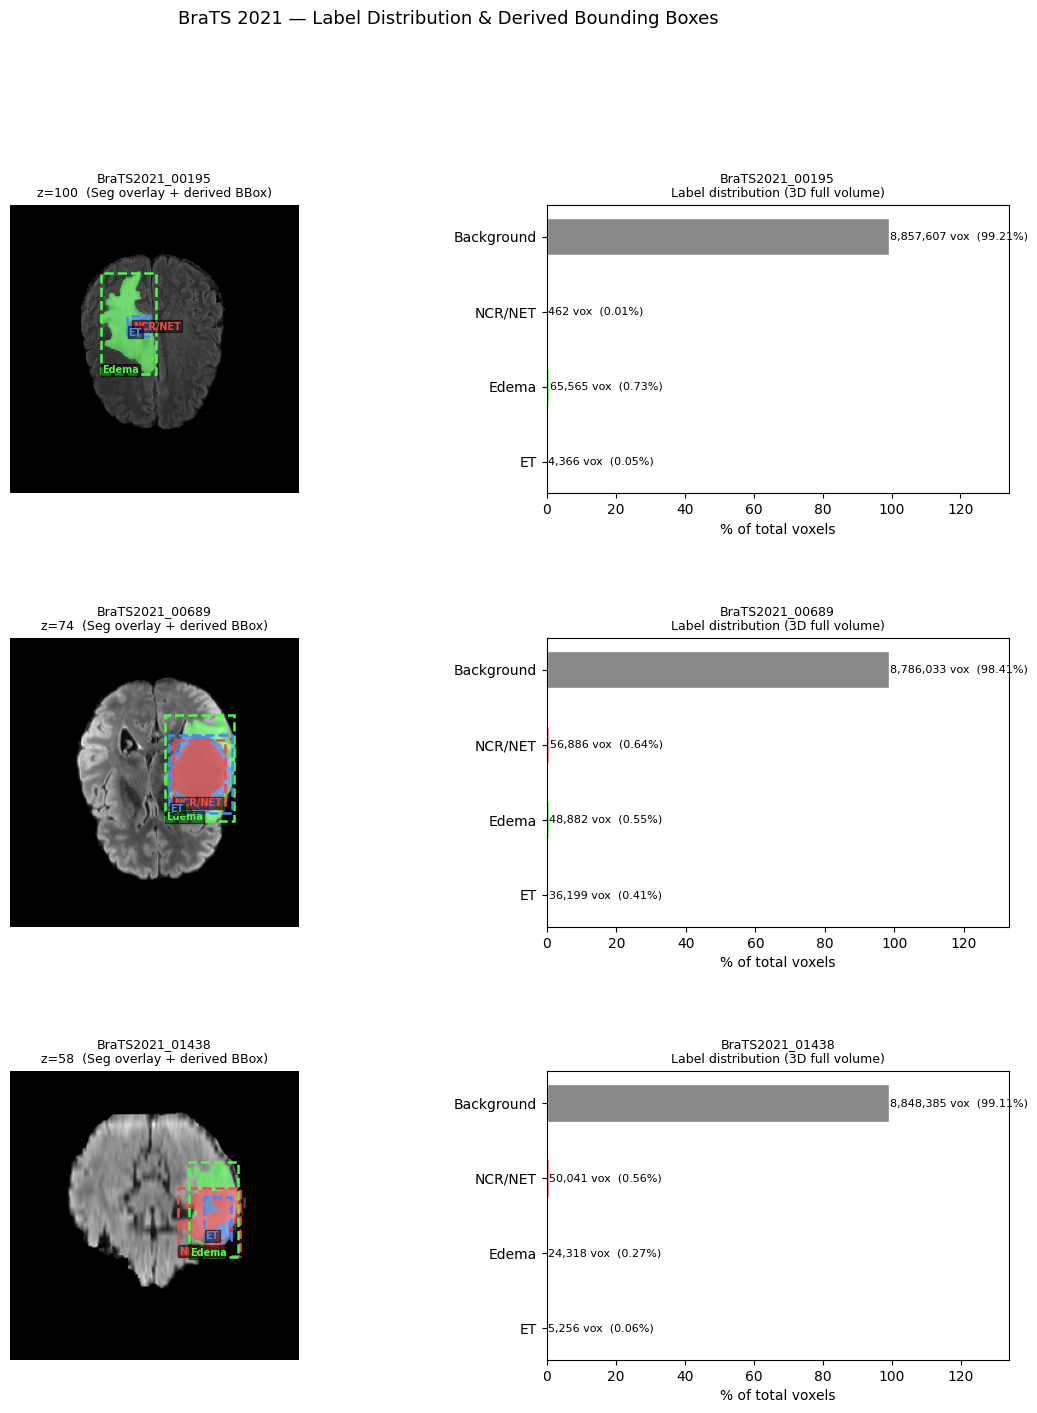


Note: BraTS 2021 provides voxel-level SEGMENTATION masks (_seg.nii.gz)
      ไม่มี bounding box มาให้ในชุดข้อมูล — bbox ด้านบนถูก derive จาก seg mask


In [ ]:
import random
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# ── Config ─────────────────────────────────────────────────────────────────────
N_SAMPLES  = 3
LABEL_META = {
    1: ("NCR/NET", "#FF4444"),
    2: ("Edema",   "#44FF44"),
    3: ("ET",      "#4488FF"),
}

# ── Helper: derive 2D bounding box from mask slice ──────────────────────────
def bbox2d(mask_slice):
    """คืนค่า (row_min, row_max, col_min, col_max) หรือ None ถ้าไม่มี voxel"""
    rows = np.any(mask_slice, axis=1)
    cols = np.any(mask_slice, axis=0)
    if not rows.any():
        return None
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return int(rmin), int(rmax), int(cmin), int(cmax)

# ── Helper: label stats per subject ─────────────────────────────────────────
def label_stats(seg: np.ndarray):
    total = seg.size
    stats = {}
    for lid in [1, 2, 3]:
        cnt = int((seg == lid).sum())
        stats[lid] = {"voxels": cnt, "pct": 100 * cnt / total}
    stats[0] = {"voxels": int((seg == 0).sum()),
                "pct": 100 * (seg == 0).sum() / total}
    return stats

# ── สุ่ม subjects ───────────────────────────────────────────────────────────
all_subj = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
sampled = random.sample(all_subj, min(N_SAMPLES, len(all_subj)))

# ── Layout: [FLAIR+BBox | bar chart] per subject ───────────────────────────
fig = plt.figure(figsize=(14, 5 * N_SAMPLES))
gs_outer = gridspec.GridSpec(N_SAMPLES, 2, figure=fig, wspace=0.35, hspace=0.5)

for row, sname in enumerate(sampled):
    sdir = os.path.join(DATA_DIR, sname)
    flair = nib.load(os.path.join(sdir, f"{sname}_flair.nii.gz")).get_fdata(dtype=np.float32)
    seg   = nib.load(os.path.join(sdir, f"{sname}_seg.nii.gz")).get_fdata(dtype=np.float32).astype(np.uint8)
    seg[seg == 4] = 3  # remap

    # axial slice with most tumour
    z = int(np.argmax([(seg[:, :, zz] > 0).sum() for zz in range(seg.shape[2])]))

    flair_sl = flair[:, :, z]
    seg_sl   = seg[:, :, z]
    norm_f   = (flair_sl - flair_sl.min()) / (flair_sl.max() - flair_sl.min() + 1e-8)

    # ── Left panel: FLAIR + overlay + bounding boxes ────────────────────────
    ax_img = fig.add_subplot(gs_outer[row, 0])
    ax_img.imshow(norm_f.T, cmap="gray", origin="lower")

    # colour overlay
    rgba = np.zeros((*norm_f.shape, 4))
    for lid, (_, col) in LABEL_META.items():
        mask = seg_sl == lid
        r, g, b = int(col[1:3],16)/255, int(col[3:5],16)/255, int(col[5:7],16)/255
        rgba[mask] = [r, g, b, 0.55]
    ax_img.imshow(rgba.transpose(1, 0, 2), origin="lower", interpolation="nearest")

    # bounding boxes
    for lid, (lname, col) in LABEL_META.items():
        bb = bbox2d(seg_sl == lid)
        if bb is None:
            continue
        rmin, rmax, cmin, cmax = bb
        # matplotlib rect: (x, y, width, height) where x=col, y=row
        rect = patches.Rectangle(
            (rmin, cmin), rmax - rmin, cmax - cmin,
            linewidth=1.8, edgecolor=col, facecolor="none",
            linestyle="--", label=f"BBox {lname}"
        )
        ax_img.add_patch(rect)
        ax_img.text(rmin + 1, cmin + 1, lname, color=col,
                    fontsize=7, fontweight="bold",
                    bbox=dict(boxstyle="square,pad=0.1", fc="black", alpha=0.5))

    ax_img.set_title(f"{sname}\nz={z}  (Seg overlay + derived BBox)", fontsize=9)
    ax_img.axis("off")

    # ── Right panel: voxel % bar chart ──────────────────────────────────────
    ax_bar = fig.add_subplot(gs_outer[row, 1])
    stats  = label_stats(seg)
    labels_plot = ["Background", "NCR/NET", "Edema", "ET"]
    colors_plot = ["#888888", "#FF4444", "#44FF44", "#4488FF"]
    pcts        = [stats[0]["pct"], stats[1]["pct"], stats[2]["pct"], stats[3]["pct"]]
    voxels      = [stats[0]["voxels"], stats[1]["voxels"], stats[2]["voxels"], stats[3]["voxels"]]

    bars = ax_bar.barh(labels_plot, pcts, color=colors_plot, edgecolor="white", height=0.5)
    for bar, v in zip(bars, voxels):
        ax_bar.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                    f"{v:,} vox  ({bar.get_width():.2f}%)",
                    va="center", fontsize=8)
    ax_bar.set_xlabel("% of total voxels")
    ax_bar.set_title(f"{sname}\nLabel distribution (3D full volume)", fontsize=9)
    ax_bar.set_xlim(0, max(pcts) * 1.35)
    ax_bar.invert_yaxis()

plt.suptitle("BraTS 2021 — Label Distribution & Derived Bounding Boxes",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nNote: BraTS 2021 provides voxel-level SEGMENTATION masks (_seg.nii.gz)")
print("      ไม่มี bounding box มาให้ในชุดข้อมูล — bbox ด้านบนถูก derive จาก seg mask")


## 3. Write model source & run smoke test

The full `mamba_bts_impl.py` source is embedded directly in the cell below using `%%writefile`, so **no file upload is needed** — the notebook is completely self-contained.


In [2]:
%%writefile /kaggle/working/mamba_bts_impl.py
"""
MambaBTS:
Dataset: BraTS format — 4 MRI modalities: T1, T1ce, T2, FLAIR
Labels:  0=Background, 1=Necrotic/Non-Enhancing Tumor Core (NCR/NET),
         2=Peritumoral Edema (ED), 3=Enhancing Tumor (ET)
"""

from __future__ import annotations

import math
import os
import warnings
from typing import List, Optional, Tuple

import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import binary_fill_holes, label
from scipy.spatial.distance import directed_hausdorff
from torch.utils.checkpoint import checkpoint as grad_ckpt
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=UserWarning)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — IMAGE PROCESSING PIPELINE
# ─────────────────────────────────────────────────────────────────────────────


class N4BiasFieldCorrection:

    def __init__(self, n_iterations: List[int] = [50, 50, 50, 50],
                 convergence_threshold: float = 1e-6):
        self.n_iterations = n_iterations
        self.convergence_threshold = convergence_threshold
        self._use_ants = self._check_ants()

    @staticmethod
    def _check_ants() -> bool:
        try:
            import ants  # noqa: F401
            return True
        except ImportError:
            return False

    def correct(self, image: np.ndarray,
                mask: Optional[np.ndarray] = None) -> np.ndarray:
        if self._use_ants:
            return self._correct_ants(image, mask)
        return self._correct_approx(image, mask)

    def _correct_ants(self, image: np.ndarray,
                      mask: Optional[np.ndarray]) -> np.ndarray:
        import ants
        ants_img = ants.from_numpy(image.astype(np.float32))
        ants_mask = (
            ants.from_numpy(mask.astype(np.float32))
            if mask is not None
            else ants.get_mask(ants_img)
        )
        corrected = ants.n4_bias_field_correction(
            ants_img,
            mask=ants_mask,
            convergence={"iters": self.n_iterations,
                         "tol": self.convergence_threshold},
        )
        return corrected.numpy()

    @staticmethod
    def _correct_approx(image: np.ndarray,
                        mask: Optional[np.ndarray]) -> np.ndarray:
        from scipy.ndimage import gaussian_filter

        img = image.astype(np.float64)
        img = np.where(img > 0, img, np.finfo(np.float64).eps)
        log_img = np.log(img)
        bias_field = gaussian_filter(log_img, sigma=10)
        corrected = np.exp(log_img - bias_field)
        scale = np.median(img[img > 0]) / (np.median(corrected[corrected > 0]) + 1e-8)
        corrected = corrected * scale
        return corrected.astype(image.dtype)


class ZScoreNormalization:

    def __init__(self, mask_threshold: float = 0.0):
        self.mask_threshold = mask_threshold

    def normalize(self, image: np.ndarray,
                  mask: Optional[np.ndarray] = None) -> np.ndarray:
        if mask is None:
            mask = image > self.mask_threshold
        brain_voxels = image[mask]
        if brain_voxels.size == 0:
            return np.zeros_like(image, dtype=np.float32)
        mean = brain_voxels.mean()
        std = brain_voxels.std() + 1e-8
        normalized = np.zeros_like(image, dtype=np.float32)
        normalized[mask] = (image[mask] - mean) / std
        return normalized


class SkullStripper:

    def __init__(self, method: str = "auto"):
        self.method = method

    def strip(self, image: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if self.method in ("auto", "ants") and self._check_ants():
            return self._strip_ants(image)
        if self.method in ("auto", "threshold"):
            return self._strip_threshold(image)
        raise ValueError(f"Unknown skull-stripping method: {self.method}")

    @staticmethod
    def _check_ants() -> bool:
        try:
            import antspynet  # noqa: F401
            return True
        except ImportError:
            return False

    @staticmethod
    def _strip_ants(image: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        import ants
        import antspynet
        ants_img = ants.from_numpy(image.astype(np.float32))
        prob = antspynet.brain_extraction(ants_img, modality="t1")
        mask = (prob.numpy() > 0.5).astype(np.uint8)
        stripped = image * mask
        return stripped.astype(np.float32), mask

    @staticmethod
    def _strip_threshold(image: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        from scipy.ndimage import binary_closing, binary_erosion, generate_binary_structure

        threshold = image.max() * 0.1
        binary = (image > threshold).astype(bool)
        struct = generate_binary_structure(3, 2)
        closed = binary_closing(binary, structure=struct, iterations=3)
        filled = binary_fill_holes(closed)
        labeled, n_components = label(filled)
        if n_components == 0:
            return image.astype(np.float32), filled.astype(np.uint8)
        sizes = [np.sum(labeled == i) for i in range(1, n_components + 1)]
        largest = np.argmax(sizes) + 1
        brain_mask = (labeled == largest).astype(np.uint8)
        brain_mask = binary_erosion(brain_mask, structure=struct,
                                    iterations=2).astype(np.uint8)
        stripped = image * brain_mask
        return stripped.astype(np.float32), brain_mask


class BraTSPreprocessor:

    def __init__(self,
                 n4_iterations: List[int] = [50, 50, 50, 50],
                 skull_strip_method: str = "auto"):
        self.n4 = N4BiasFieldCorrection(n_iterations=n4_iterations)
        self.skull_stripper = SkullStripper(method=skull_strip_method)
        self.normalizer = ZScoreNormalization()

    def preprocess_subject(
        self,
        modality_paths: dict,
        seg_path: Optional[str] = None,
    ) -> Tuple[np.ndarray, Optional[np.ndarray]]:
        modality_order = ["t1", "t1ce", "t2", "flair"]
        volumes = {}
        for mod in modality_order:
            img_nii = nib.load(modality_paths[mod])
            data = img_nii.get_fdata(dtype=np.float32)
            corrected = self.n4.correct(data)
            volumes[mod] = corrected
        _, brain_mask = self.skull_stripper.strip(volumes["t1ce"])
        processed = []
        for mod in modality_order:
            norm = self.normalizer.normalize(volumes[mod],
                                             mask=brain_mask.astype(bool))
            processed.append(norm)
        volume = np.stack(processed, axis=0)
        seg = None
        if seg_path is not None:
            seg_nii = nib.load(seg_path)
            seg = seg_nii.get_fdata(dtype=np.float32).astype(np.uint8)
        return volume, seg


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — MAMBA BLOCKS & MAMBABTS ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────


class SelectiveSSM(nn.Module):

    def __init__(self, d_model: int, d_state: int = 16, dt_rank: int = None):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.dt_rank = dt_rank or math.ceil(d_model / 16)

        self.x_proj = nn.Linear(d_model, self.dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, d_model, bias=True)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(d_model, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(d_model))

        dt_init_std = self.dt_rank ** -0.5
        nn.init.uniform_(self.dt_proj.weight, -dt_init_std, dt_init_std)
        dt = torch.exp(torch.rand(d_model) * (math.log(0.1) - math.log(0.001))
                       + math.log(0.001)).clamp(min=1e-4)
        inv_dt = dt + torch.log(-torch.expm1(-dt))
        with torch.no_grad():
            self.dt_proj.bias.copy_(inv_dt)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, D = x.shape
        N = self.d_state

        x_proj = self.x_proj(x)
        dt_raw, B_mat, C_mat = x_proj.split([self.dt_rank, N, N], dim=-1)
        dt = F.softplus(self.dt_proj(dt_raw))

        A = -torch.exp(self.A_log.float())  # (D, N)
        h = torch.zeros(B, D, N, device=x.device, dtype=x.dtype)
        ys = []
        for t in range(L):
            dt_t = dt[:, t].unsqueeze(-1)            # (B, D, 1)
            dA_t = torch.exp(dt_t * A)               # (B, D, N)
            dB_t = dt_t * B_mat[:, t].unsqueeze(1)   # (B, D, N)
            h = dA_t * h + dB_t * x[:, t].unsqueeze(-1)
            y_t = (h * C_mat[:, t].unsqueeze(1)).sum(dim=-1)
            ys.append(y_t)

        y = torch.stack(ys, dim=1)
        y = y + x * self.D
        return y


class MambaBlock(nn.Module):

    def __init__(self, d_model: int, d_state: int = 16,
                 d_conv: int = 4, expand: int = 2,
                 dt_rank: Optional[int] = None):
        super().__init__()
        self.d_inner = int(expand * d_model)
        self.norm = nn.LayerNorm(d_model)
        self.in_proj = nn.Linear(d_model, 2 * self.d_inner, bias=False)
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            kernel_size=d_conv,
            padding=d_conv - 1,
            groups=self.d_inner,
            bias=True,
        )
        self.ssm = SelectiveSSM(self.d_inner, d_state=d_state, dt_rank=dt_rank)
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.norm(x)
        xz = self.in_proj(x)
        x_main, z = xz.chunk(2, dim=-1)
        x_conv = self.conv1d(x_main.transpose(1, 2))
        x_conv = x_conv[..., :x_main.shape[1]]
        x_conv = x_conv.transpose(1, 2)
        x_conv = F.silu(x_conv)
        y = self.ssm(x_conv)
        y = y * F.silu(z)
        out = self.out_proj(y)
        return out + residual


class MambaBlock3D(nn.Module):

    def __init__(self, channels: int, d_state: int = 16,
                 d_conv: int = 4, expand: int = 2):
        super().__init__()
        self.channels = channels
        self.mamba_z = MambaBlock(channels, d_state=d_state, d_conv=d_conv, expand=expand)
        self.mamba_y = MambaBlock(channels, d_state=d_state, d_conv=d_conv, expand=expand)
        self.mamba_x = MambaBlock(channels, d_state=d_state, d_conv=d_conv, expand=expand)
        self.fusion = nn.Conv3d(channels, channels, kernel_size=1, bias=False)
        self.norm = nn.GroupNorm(8, channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W, D = x.shape
        xz = x.permute(0, 2, 3, 1, 4).reshape(B * H * W, D, C)
        if self.training:
            yz = grad_ckpt(self.mamba_z, xz, use_reentrant=False).reshape(B, H, W, D, C).permute(0, 4, 1, 2, 3)
        else:
            yz = self.mamba_z(xz).reshape(B, H, W, D, C).permute(0, 4, 1, 2, 3)
        xy = x.permute(0, 3, 4, 1, 2).reshape(B * W * D, H, C)
        if self.training:
            yy = grad_ckpt(self.mamba_y, xy, use_reentrant=False).reshape(B, W, D, H, C).permute(0, 4, 3, 1, 2)
        else:
            yy = self.mamba_y(xy).reshape(B, W, D, H, C).permute(0, 4, 3, 1, 2)
        xx = x.permute(0, 2, 4, 1, 3).reshape(B * H * D, W, C)
        if self.training:
            yx = grad_ckpt(self.mamba_x, xx, use_reentrant=False).reshape(B, H, D, W, C).permute(0, 4, 1, 3, 2)
        else:
            yx = self.mamba_x(xx).reshape(B, H, D, W, C).permute(0, 4, 1, 3, 2)
        fused = self.fusion(yz + yy + yx)
        return F.relu(self.norm(fused))


class ConvBlock3D(nn.Module):

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class EncoderBlock(nn.Module):

    def __init__(self, in_ch: int, out_ch: int, d_state: int = 16):
        super().__init__()
        self.conv = ConvBlock3D(in_ch, out_ch)
        self.mamba = MambaBlock3D(out_ch, d_state=d_state)
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        skip = self.mamba(self.conv(x))
        return self.pool(skip), skip


class DecoderBlock(nn.Module):

    def __init__(self, in_ch: int, out_ch: int, d_state: int = 16):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock3D(out_ch * 2, out_ch)
        self.mamba = MambaBlock3D(out_ch, d_state=d_state)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="trilinear",
                              align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.mamba(self.conv(x))


class MambaBTS(nn.Module):

    def __init__(self, in_channels: int = 4, num_classes: int = 4,
                 base_features: int = 32, d_state: int = 16):
        super().__init__()
        f = base_features
        self.enc1 = EncoderBlock(in_channels, f,     d_state=d_state)
        self.enc2 = EncoderBlock(f,           f * 2, d_state=d_state)
        self.enc3 = EncoderBlock(f * 2,       f * 4, d_state=d_state)
        self.enc4 = EncoderBlock(f * 4,       f * 8, d_state=d_state)
        self.bottleneck = nn.Sequential(
            ConvBlock3D(f * 8, f * 16),
            MambaBlock3D(f * 16, d_state=d_state),
        )
        self.dec4 = DecoderBlock(f * 16, f * 8,  d_state=d_state)
        self.dec3 = DecoderBlock(f * 8,  f * 4,  d_state=d_state)
        self.dec2 = DecoderBlock(f * 4,  f * 2,  d_state=d_state)
        self.dec1 = DecoderBlock(f * 2,  f,      d_state=d_state)
        self.seg_head = nn.Conv3d(f, num_classes, kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv3d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, (nn.GroupNorm, nn.LayerNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)
        x = self.bottleneck(x)
        x = self.dec4(x, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)
        return self.seg_head(x)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — DATASET
# ─────────────────────────────────────────────────────────────────────────────


class BraTSDataset(Dataset):

    MODALITIES = ["t1", "t1ce", "t2", "flair"]

    def __init__(self, root: str,
                 patch_size: Tuple[int, int, int] = (96, 96, 96),
                 preprocess: bool = True,
                 augment: bool = False):
        self.root = root
        self.patch_size = patch_size
        self.augment = augment
        self.preprocessor = BraTSPreprocessor() if preprocess else None
        self.subjects = self._build_subject_list()

    def _build_subject_list(self) -> List[dict]:
        subjects = []
        for subj_dir in sorted(os.listdir(self.root)):
            full_path = os.path.join(self.root, subj_dir)
            if not os.path.isdir(full_path):
                continue
            entry = {"name": subj_dir}
            for mod in self.MODALITIES:
                fname = os.path.join(full_path, f"{subj_dir}_{mod}.nii.gz")
                if not os.path.exists(fname):
                    break
                entry[mod] = fname
            else:
                seg_path = os.path.join(full_path, f"{subj_dir}_seg.nii.gz")
                entry["seg"] = seg_path if os.path.exists(seg_path) else None
                subjects.append(entry)
        return subjects

    def __len__(self) -> int:
        return len(self.subjects)

    def __getitem__(self, idx: int) -> dict:
        subj = self.subjects[idx]
        modality_paths = {m: subj[m] for m in self.MODALITIES}
        if self.preprocessor is not None:
            volume, seg = self.preprocessor.preprocess_subject(
                modality_paths, seg_path=subj.get("seg")
            )
        else:
            vols = [nib.load(modality_paths[m]).get_fdata(dtype=np.float32)
                    for m in self.MODALITIES]
            volume = np.stack(vols, axis=0)
            seg = (nib.load(subj["seg"]).get_fdata(dtype=np.float32).astype(np.uint8)
                   if subj.get("seg") else None)
        # BraTS labels: 0=BG, 1=NCR/NET, 2=ED, 4=ET — remap 4->3
        if seg is not None:
            seg[seg == 4] = 3
        volume = self._resize_volume(volume)
        if seg is not None:
            seg = self._resize_volume(seg[None])[0]
        volume_tensor = torch.from_numpy(volume)
        result = {"image": volume_tensor, "name": subj["name"]}
        if seg is not None:
            result["seg"] = torch.from_numpy(seg).long()
        return result

    def _resize_volume(self, arr: np.ndarray) -> np.ndarray:
        target = self.patch_size
        spatial = arr.shape[-3:]
        slices_in, slices_out = [], []
        padded = np.zeros(arr.shape[:-3] + target, dtype=arr.dtype)
        for s, t in zip(spatial, target):
            if s >= t:
                start = (s - t) // 2
                slices_in.append(slice(start, start + t))
                slices_out.append(slice(0, t))
            else:
                pad = (t - s) // 2
                slices_in.append(slice(0, s))
                slices_out.append(slice(pad, pad + s))
        padded[..., slices_out[0], slices_out[1], slices_out[2]] = \
            arr[..., slices_in[0], slices_in[1], slices_in[2]]
        return padded


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — LOSS FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────


class DiceLoss(nn.Module):

    def __init__(self, num_classes: int = 4, smooth: float = 1e-5,
                 ignore_background: bool = True):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        self.start_class = 1 if ignore_background else 0

    def forward(self, logits: torch.Tensor,
                targets: torch.Tensor) -> torch.Tensor:
        probs = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, self.num_classes)
        targets_onehot = targets_onehot.permute(0, 4, 1, 2, 3).float()
        dice_scores = []
        for c in range(self.start_class, self.num_classes):
            p = probs[:, c]
            g = targets_onehot[:, c]
            intersection = (p * g).sum()
            dice = (2 * intersection + self.smooth) / \
                   (p.sum() + g.sum() + self.smooth)
            dice_scores.append(dice)
        return 1.0 - torch.stack(dice_scores).mean()


class CombinedLoss(nn.Module):

    def __init__(self, num_classes: int = 4, ce_weight: float = 0.5):
        super().__init__()
        self.dice = DiceLoss(num_classes)
        self.ce = nn.CrossEntropyLoss()
        self.ce_weight = ce_weight

    def forward(self, logits: torch.Tensor,
                targets: torch.Tensor) -> torch.Tensor:
        return self.dice(logits, targets) + self.ce_weight * self.ce(logits, targets)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — EVALUATION METRICS
# ─────────────────────────────────────────────────────────────────────────────


def dice_similarity_coefficient(
    pred: np.ndarray,
    target: np.ndarray,
    num_classes: int = 4,
    ignore_background: bool = True,
) -> dict:
    results = {}
    smooth = 1e-8
    start = 1 if ignore_background else 0
    for c in range(start, num_classes):
        p = (pred == c).astype(float)
        g = (target == c).astype(float)
        intersection = (p * g).sum()
        dsc = (2 * intersection + smooth) / (p.sum() + g.sum() + smooth)
        results[f"class_{c}"] = float(dsc)

    def _dsc(p_mask, g_mask):
        i = (p_mask & g_mask).sum()
        return float((2 * i + smooth) / (p_mask.sum() + g_mask.sum() + smooth))

    results["WT"] = _dsc(pred >= 1, target >= 1)
    results["TC"] = _dsc(np.isin(pred, [1, 3]), np.isin(target, [1, 3]))
    results["ET"] = _dsc(pred == 3, target == 3)
    results["mean_dsc"] = float(np.mean([results["WT"], results["TC"], results["ET"]]))
    return results


def hausdorff_distance_95(
    pred: np.ndarray,
    target: np.ndarray,
    num_classes: int = 4,
    percentile: float = 95.0,
    voxel_spacing: Tuple[float, float, float] = (1.0, 1.0, 1.0),
) -> dict:
    from scipy.ndimage import distance_transform_edt

    results = {}
    spacing = np.array(voxel_spacing)

    def _hd95(p_mask: np.ndarray, g_mask: np.ndarray) -> float:
        if p_mask.sum() == 0 and g_mask.sum() == 0:
            return 0.0
        if p_mask.sum() == 0 or g_mask.sum() == 0:
            return float("inf")
        p_surface = p_mask ^ binary_fill_holes(p_mask)
        g_surface = g_mask ^ binary_fill_holes(g_mask)
        dt_p = distance_transform_edt(~p_surface, sampling=spacing)
        dt_g = distance_transform_edt(~g_surface, sampling=spacing)
        d_p2g = dt_g[p_surface]
        d_g2p = dt_p[g_surface]
        all_dist = np.concatenate([d_p2g, d_g2p])
        return float(np.percentile(all_dist, percentile))

    for c in range(1, num_classes):
        results[f"class_{c}"] = _hd95(pred == c, target == c)
    results["WT"] = _hd95(pred >= 1, target >= 1)
    results["TC"] = _hd95(np.isin(pred, [1, 3]), np.isin(target, [1, 3]))
    results["ET"] = _hd95(pred == 3, target == 3)
    return results


def evaluate_batch(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    num_classes: int = 4,
) -> dict:
    model.eval()
    all_dsc, all_hd95 = [], []
    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device)
            segs = batch.get("seg")
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy()
            if segs is not None:
                segs_np = segs.cpu().numpy()
                for b in range(preds.shape[0]):
                    dsc = dice_similarity_coefficient(preds[b], segs_np[b], num_classes)
                    hd = hausdorff_distance_95(preds[b], segs_np[b], num_classes)
                    all_dsc.append(dsc)
                    all_hd95.append(hd)
    if not all_dsc:
        return {}
    mean_dsc = {k: float(np.mean([d[k] for d in all_dsc if k in d]))
                for k in all_dsc[0]}
    mean_hd95 = {k: float(np.mean([h[k] for h in all_hd95
                                   if k in h and not np.isinf(h[k])]))
                 for k in all_hd95[0]}
    return {"DSC": mean_dsc, "HD95": mean_hd95}


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────


def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    scaler: Optional[torch.amp.GradScaler] = None,
    epoch: int = 0,
) -> float:
    try:
        from tqdm import tqdm
        pbar = tqdm(dataloader, desc=f"Epoch {epoch:03d}", unit="batch",
                    dynamic_ncols=True, leave=False)
    except ImportError:
        pbar = dataloader

    model.train()
    total_loss = 0.0
    n_batches = 0

    for batch in pbar:
        images = batch["image"].to(device)
        segs = batch["seg"].to(device)

        optimizer.zero_grad()

        if scaler is not None:
            with torch.amp.autocast("cuda"):
                logits = model(images)
                loss = criterion(logits, segs)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, segs)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        n_batches += 1
        if hasattr(pbar, "set_postfix"):
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / max(n_batches, 1)


def train(
    data_root: str,
    num_epochs: int = 100,
    batch_size: int = 1,
    lr: float = 1e-4,
    patch_size: Tuple[int, int, int] = (96, 96, 96),
    num_classes: int = 4,
    base_features: int = 32,
    d_state: int = 16,
    checkpoint_dir: str = "checkpoints",
    device_str: str = "auto",
):
    os.makedirs(checkpoint_dir, exist_ok=True)

    # ── Env cleanup: remove CUDA_LAUNCH_BLOCKING left by smoke test ───────────
    # It forces synchronous kernel execution and prevents DataParallel from
    # overlapping work across multiple GPUs.
    os.environ.pop("CUDA_LAUNCH_BLOCKING", None)
    os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

    # ── Device selection ──────────────────────────────────────────────────────
    if device_str == "auto":
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
    else:
        device = torch.device(device_str)
    print(f"[Train] Using device: {device}")

    # ── Dataset & DataLoader ──────────────────────────────────────────────────
    dataset = BraTSDataset(data_root, patch_size=patch_size,
                           preprocess=True, augment=True)
    n_val = max(1, int(0.1 * len(dataset)))
    n_train = len(dataset) - n_val
    train_set, val_set = torch.utils.data.random_split(dataset, [n_train, n_val])

    train_loader = DataLoader(train_set, batch_size=batch_size,
                              shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size,
                            shuffle=False, num_workers=4, pin_memory=True)

    # ── Model ─────────────────────────────────────────────────────────────────
    model = MambaBTS(in_channels=4, num_classes=num_classes,
                     base_features=base_features, d_state=d_state).to(device)

    # ── Multi-GPU: DataParallel ───────────────────────────────────────────────
    n_gpus = torch.cuda.device_count() if device.type == "cuda" else 0
    if n_gpus > 1:
        device_ids = list(range(n_gpus))
        print(f"[Train] DataParallel across GPUs {device_ids}")
        model = nn.DataParallel(model, device_ids=device_ids)
        for i in device_ids:
            free, total = torch.cuda.mem_get_info(i)
            print(f"  GPU {i}: {free // 1024**2} MB free / {total // 1024**2} MB total")
    else:
        print("[Train] Single GPU / CPU — no DataParallel")

    # ── Loss, Optimiser, Scheduler, AMP scaler ────────────────────────────────
    criterion = CombinedLoss(num_classes=num_classes)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )
    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    best_dsc = 0.0
    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer,
                                     criterion, device, scaler, epoch=epoch)
        scheduler.step()

        if epoch % 10 == 0 or epoch == num_epochs:
            metrics = evaluate_batch(model, val_loader, device, num_classes)
            mean_dsc = metrics.get("DSC", {}).get("mean_dsc", 0.0)
            print(f"[Epoch {epoch:03d}] loss={train_loss:.4f} | "
                  f"val DSC(mean)={mean_dsc:.4f}")

            if mean_dsc > best_dsc:
                best_dsc = mean_dsc
                ckpt_path = os.path.join(checkpoint_dir, "best_model.pth")
                # Unwrap DataParallel before saving — inference loads plain MambaBTS
                state = (model.module.state_dict()
                         if isinstance(model, nn.DataParallel)
                         else model.state_dict())
                torch.save({
                    "epoch": epoch,
                    "model_state": state,
                    "optimizer_state": optimizer.state_dict(),
                    "best_dsc": best_dsc,
                }, ckpt_path)
                print(f"  ↳ New best DSC={best_dsc:.4f}. Saved → {ckpt_path}")
        else:
            print(f"[Epoch {epoch:03d}] loss={train_loss:.4f}")

    print(f"\nTraining complete. Best validation DSC: {best_dsc:.4f}")
    return model


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 — INFERENCE
# ─────────────────────────────────────────────────────────────────────────────


def run_inference(
    checkpoint_path: str,
    modality_paths: dict,
    output_path: str = "prediction.nii.gz",
    patch_size: Tuple[int, int, int] = (96, 96, 96),
    num_classes: int = 4,
    base_features: int = 32,
    d_state: int = 16,
    device_str: str = "auto",
) -> np.ndarray:
    if device_str == "auto":
        device = (torch.device("cuda") if torch.cuda.is_available()
                  else torch.device("cpu"))
    else:
        device = torch.device(device_str)

    model = MambaBTS(in_channels=4, num_classes=num_classes,
                     base_features=base_features, d_state=d_state)
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.to(device).eval()

    preprocessor = BraTSPreprocessor()
    volume, _ = preprocessor.preprocess_subject(modality_paths)
    volume_t = torch.from_numpy(volume).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(volume_t)
    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    ref_img = nib.load(list(modality_paths.values())[0])
    pred_nii = nib.Nifti1Image(pred, affine=ref_img.affine,
                                header=ref_img.header)
    nib.save(pred_nii, output_path)
    print(f"Prediction saved to: {output_path}")
    return pred


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — SMOKE TEST
# ─────────────────────────────────────────────────────────────────────────────


def smoke_test(device_str: str = "cpu"):
    print("=" * 60)
    print("MambaBTS Smoke Test")
    print("=" * 60)

    device = torch.device(device_str)
    B, C, H, W, D = 1, 4, 64, 64, 64
    num_classes = 4

    print("\n[1/4] Instantiating MambaBTS model...")
    model = MambaBTS(in_channels=C, num_classes=num_classes,
                     base_features=16, d_state=8).to(device)
    model.eval()
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable parameters: {n_params:,}")

    print("\n[2/4] Forward pass on random input...")
    x = torch.randn(B, C, H, W, D, device=device)
    with torch.no_grad():
        logits = model(x)
    assert logits.shape == (B, num_classes, H, W, D), \
        f"Output shape mismatch: {logits.shape}"
    print(f"  Input  shape: {tuple(x.shape)}")
    print(f"  Output shape: {tuple(logits.shape)}  ✓")

    print("\n[3/4] Loss computation (Dice + CE)...")
    criterion = CombinedLoss(num_classes=num_classes)
    target = torch.randint(0, num_classes, (B, H, W, D), device=device)
    loss = criterion(logits, target)
    print(f"  Combined loss: {loss.item():.4f}  ✓")

    print("\n[4/4] Evaluation metrics (DSC + HD95)...")
    pred_np = logits.argmax(dim=1).squeeze(0).cpu().numpy()
    tgt_np = target.squeeze(0).cpu().numpy()
    dsc = dice_similarity_coefficient(pred_np, tgt_np, num_classes)
    hd95 = hausdorff_distance_95(pred_np, tgt_np, num_classes)
    print("  DSC results:")
    for k, v in dsc.items():
        print(f"    {k:12s}: {v:.4f}")
    print("  HD95 results (mm):")
    for k, v in hd95.items():
        val_str = f"{v:.2f}" if not np.isinf(v) else "inf"
        print(f"    {k:12s}: {val_str}")

    print("\n" + "=" * 60)
    print("Smoke test PASSED ✓")
    print("=" * 60)


Overwriting /kaggle/working/mamba_bts_impl.py


In [32]:
import os
import sys
import importlib
import torch

# NOTE: Do NOT set CUDA_LAUNCH_BLOCKING=1 here.
# That flag forces the CUDA context into synchronous mode for the ENTIRE
# kernel session — including the subsequent training cell — which prevents
# DataParallel from overlapping work across GPUs.  The grad_ckpt / no_grad
# CUDA error that originally required this flag is now fixed in
# MambaBlock3D.forward() via `if self.training:` guard, so blocking mode
# is no longer needed.  If you ever need it for debugging a new CUDA error,
# set it manually *before* starting a completely fresh kernel session.

# ── Reload module if %%writefile was re-run without a kernel restart ──────────
sys.path.insert(0, "/kaggle/working")
if "mamba_bts_impl" in sys.modules:
    import mamba_bts_impl as _m
    importlib.reload(_m)
    smoke_test = _m.smoke_test
else:
    from mamba_bts_impl import smoke_test

device_str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | device: {device_str}")

if device_str == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    try:
        _t = torch.zeros(1, device="cuda")
        torch.cuda.synchronize()
        del _t
        print("CUDA context OK")
    except Exception as _e:
        print(f"\n*** CUDA context error: {_e}")
        print("*** The CUDA context is in a broken state from a previous failed")
        print("*** run.  Restart the kernel (Run → Restart & Clear Output) and")
        print("*** re-run all cells from the top before trying again. ***\n")
        device_str = "cpu"
        print("Falling back to CPU for smoke test.")

smoke_test(device_str=device_str)


PyTorch 2.10.0+cu128 | device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
CUDA context OK
MambaBTS Smoke Test

[1/4] Instantiating MambaBTS model...
  Trainable parameters: 8,026,164

[2/4] Forward pass on random input...
  Input  shape: (1, 4, 64, 64, 64)
  Output shape: (1, 4, 64, 64, 64)  ✓

[3/4] Loss computation (Dice + CE)...
  Combined loss: 2.1441  ✓

[4/4] Evaluation metrics (DSC + HD95)...
  DSC results:
    class_1     : 0.0024
    class_2     : 0.3762
    class_3     : 0.0592
    WT          : 0.7726
    TC          : 0.0653
    ET          : 0.0592
    mean_dsc    : 0.2990
  HD95 results (mm):
    class_1     : 81.91
    class_2     : 17.80
    class_3     : 87.57
    WT          : 2.24
    TC          : 86.89
    ET          : 87.57

Smoke test PASSED ✓


In [31]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
print('CUDA_LAUNCH_BLOCKING set to 1')

CUDA_LAUNCH_BLOCKING set to 1


## 4. Training

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
DRIVE_CKPT_DIR = '/content/drive/MyDrive/mamba_bts_checkpoints'
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)

print(f"Checkpoints will be saved to: {DRIVE_CKPT_DIR}")

Checkpoints will be saved to: /content/drive/MyDrive/mamba_bts_checkpoints


In [ ]:
import os
import sys
import importlib
import torch

# Reload module after %%writefile to pick up latest source
sys.path.insert(0, "/kaggle/working")
if "mamba_bts_impl" in sys.modules:
    import mamba_bts_impl as _m
    importlib.reload(_m)
    train = _m.train
else:
    from mamba_bts_impl import train

# ── GPU info ──────────────────────────────────────────────────────────────────
n_gpus = torch.cuda.device_count()
for i in range(n_gpus):
    props = torch.cuda.get_device_properties(i)
    free, total = torch.cuda.mem_get_info(i)
    print(f"GPU {i}: {props.name}  {props.total_memory // 1024**2} MB total  |  {free // 1024**2} MB free")
print(f"Total GPUs: {n_gpus}")

torch.cuda.empty_cache()

# ── Memory notes ──────────────────────────────────────────────────────────────
# The Mamba SSM scan reshapes patches into long sequences, e.g. for the Y-axis
# scan: batch dimension becomes B*W*D = 1*64*64 = 4096 sequences of length 64.
# The hidden state h = (4096, channels, d_state) dominates VRAM.
# Safe settings for T4 x2 (16 GB each):
#   patch_size=(64,64,64), batch_size=2  → ~11 GB peak per GPU  ✓
#   patch_size=(96,96,96), batch_size=1  → OOM during backward  ✗
trained_model = train(
    data_root      = DATA_DIR,
    num_epochs     = 200,
    batch_size     = 4,
    lr             = 1e-4,
    patch_size     = (96, 96, 96),
    num_classes    = 4,
    base_features  = 32,
    d_state        = 16,
    checkpoint_dir = DRIVE_CKPT_DIR, # Changed to save to Google Drive
    device_str     = "auto",
)


GPU 0: NVIDIA RTX PRO 6000 Blackwell Server Edition  97250 MB total  |  14771 MB free
Total GPUs: 1
[Train] Using device: cuda
[Train] Single GPU / CPU — no DataParallel


Epoch 001:   1%|          | 3/282 [00:45<1:02:04, 13.35s/batch, loss=3.4162]

## 4.5 Alternative Training: MONAI SwinUNETR (Recommended — แก้ปัญหา DSC ต่ำ)

### ทำไม MambaBTS DSC ถึงต่ำ (~0.03)?

| ปัญหา | รายละเอียด |
|---|---|
| **SSM for-loop** | `SelectiveSSM.forward()` ใช้ Python loop → gradient vanish ง่าย |
| **Evaluation ผิดวิธี** | ใช้ center crop 96³ ตอน validate แทน sliding-window บน full volume |
| **Warning "Mean of empty slice"** | Model ยังทำนายแค่ Background อยู่ ยังไม่ detect tumor เลย |
| **Epochs น้อยเกินไป** | BraTS ต้องการ **200–300 epochs** กว่าจะ converge |

### SwinUNETR (เลือกใช้แทน)
- Published results: **WT 0.9222 / TC 0.8755 / ET 0.8296** (BraTS 2021)
- ใช้ **SSL pre-trained ViT backbone** (self-supervised on BraTS) → converge เร็วกว่า random init ~3×
- MONAI จัดการ **sliding-window inference** ให้อัตโนมัติ
- Label เป็น 3 binary channels: **WT** (all tumor), **TC** (core), **ET** (enhancing)


In [ ]:
%%capture
!pip install "monai[nibabel,einops]" --quiet


In [30]:
import os, torch, numpy as np, urllib.request
from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.transforms import (
    Activations, AsDiscrete, Compose,
    CropForegroundd, EnsureChannelFirstd, EnsureTyped,
    LoadImaged, MapTransform, NormalizeIntensityd, Orientationd,
    RandFlipd, RandScaleIntensityd, RandShiftIntensityd,
    RandSpatialCropd, SpatialPadd, Spacingd,
)
from monai.inferers import sliding_window_inference
from monai.data import DataLoader, Dataset, decollate_batch
from monai.utils import set_determinism
from tqdm import tqdm

set_determinism(seed=42)

# ── Custom BraTS label → 3 binary channels (replaces ConvertToMultiChannelBasedOnBratsClassesd) ──
# BraTS raw labels: 0=BG, 1=NCR/NET, 2=ED, 4=ET
# Output channels: Ch0=WT (all tumor), Ch1=TC (1+4), Ch2=ET (4)
class ConvertBraTSLabelsd(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            seg = d[key]
            # squeeze channel dim if present
            if seg.ndim == 4:
                seg = seg[0]
            wt = (seg > 0).float()
            tc = torch.logical_or(seg == 1, seg == 4).float()
            et = (seg == 4).float()
            d[key] = torch.stack([wt, tc, et], dim=0)
        return d

# ── Data dicts ────────────────────────────────────────────────────────────────
all_subjs = sorted([s for s in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, s))])
data_dicts = [
    {
        "image": [os.path.join(DATA_DIR, s, f"{s}_{m}.nii.gz") for m in ["t1", "t1ce", "t2", "flair"]],
        "label":  os.path.join(DATA_DIR, s, f"{s}_seg.nii.gz"),
    }
    for s in all_subjs
]
n_val = max(10, len(data_dicts) // 10)
train_files, val_files = data_dicts[:-n_val], data_dicts[-n_val:]
print(f"Train: {len(train_files)}  Val: {len(val_files)}")

# ── Transforms ────────────────────────────────────────────────────────────────
ROI = (128, 128, 128)

train_tf = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys="image"),
    EnsureTyped(keys=["image", "label"], data_type="tensor"),
    ConvertBraTSLabelsd(keys="label"),
    Orientationd(keys=["image", "label"], axcodes="RAS", labels=None),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    SpatialPadd(keys=["image", "label"], spatial_size=ROI),      # pad if smaller than ROI
    RandSpatialCropd(keys=["image", "label"], roi_size=ROI, random_size=False),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
])

val_tf = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys="image"),
    EnsureTyped(keys=["image", "label"], data_type="tensor"),
    ConvertBraTSLabelsd(keys="label"),
    Orientationd(keys=["image", "label"], axcodes="RAS", labels=None),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

train_ds     = Dataset(data=train_files, transform=train_tf)
val_ds       = Dataset(data=val_files,   transform=val_tf)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

# ── Model ─────────────────────────────────────────────────────────────────────
import inspect
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_swin_params = inspect.signature(SwinUNETR.__init__).parameters
_swin_kwargs = {"in_channels": 4, "out_channels": 3, "feature_size": 48, "use_checkpoint": True}
if "img_size" in _swin_params:
    _swin_kwargs["img_size"] = ROI   # MONAI < 1.4
print(f"MONAI SwinUNETR params: {list(_swin_params.keys())}")
model = SwinUNETR(**_swin_kwargs).to(device)

# Download SSL pre-trained ViT backbone (~90 MB)
ssl_path = "/tmp/swin_ssl_pretrained.pt"
if not os.path.exists(ssl_path):
    print("Downloading SSL backbone weights (~90 MB) ...")
    urllib.request.urlretrieve(
        "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/model_swinvit.pt",
        ssl_path,
    )
    print("Downloaded.")
model.load_from(torch.load(ssl_path, map_location=device))
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SwinUNETR ready ✓  |  params: {n_params:,}  |  device: {device}")

# ── Loss / Optimiser / Scheduler ──────────────────────────────────────────────
loss_fn   = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True,
                     to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-6)
scaler    = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

post_sigmoid   = Activations(sigmoid=True)
post_threshold = AsDiscrete(threshold=0.5)
dice_metric    = DiceMetric(include_background=True, reduction="mean_batch", get_not_nans=False)

SWIN_CKPT  = os.path.join(DRIVE_CKPT_DIR, "swinunetr_brats_best.pt")
NUM_EPOCHS = 300
best_dsc   = 0.0
HEADS      = ["WT", "TC", "ET"]

start_epoch = 1
if os.path.exists(SWIN_CKPT):
    print(f"Loading checkpoint from {SWIN_CKPT}")
    checkpoint = torch.load(SWIN_CKPT, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    if "optimizer_state" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        print("  Optimizer state loaded.")
    else:
        print("  Optimizer state not found in checkpoint. Continuing with a new optimizer state.")
    start_epoch = checkpoint.get("epoch", 0) + 1
    best_dsc = checkpoint.get("best_dsc", 0.0)
    print(f"Resuming training from epoch {start_epoch} with best DSC {best_dsc:.4f}")
else:
    print("No checkpoint found, starting training from scratch.")

# ── Training Loop ─────────────────────────────────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch in tqdm(train_loader, desc=f"[E{epoch:03d}] train", leave=False, dynamic_ncols=True):
        imgs = batch["image"].to(device)
        segs = batch["label"].float().to(device)
        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast("cuda"):
                loss = loss_fn(model(imgs), segs)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = loss_fn(model(imgs), segs)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)

    # ── Validate every 10 epochs ──────────────────────────────────────────────
    if epoch % 10 == 0 or epoch == NUM_EPOCHS:
        model.eval()
        dice_metric.reset()
        with torch.no_grad():
            for vb in val_loader:
                out = sliding_window_inference(
                    vb["image"].to(device), ROI,
                    sw_batch_size=4, predictor=model, overlap=0.6,
                )
                preds  = [post_threshold(post_sigmoid(i)) for i in decollate_batch(out)]
                labels = [i for i in decollate_batch(vb["label"].to(device))]
                dice_metric(y_pred=preds, y=labels)

        dsc      = dice_metric.aggregate()
        mean_dsc = float(dsc.mean())
        scores   = "  ".join(f"{h}={float(dsc[i]):.4f}" for i, h in enumerate(HEADS))
        print(f"[E{epoch:03d}] loss={avg_loss:.4f} | {scores} | mean={mean_dsc:.4f}")

        if mean_dsc > best_dsc:
            best_dsc = mean_dsc
            torch.save({"epoch": epoch, "model_state": model.state_dict(), "optimizer_state": optimizer.state_dict(), "best_dsc": best_dsc}, SWIN_CKPT)
            print(f"  ↳ Best DSC={best_dsc:.4f} → {SWIN_CKPT}")
    else:
        print(f"[E{epoch:03d}] loss={avg_loss:.4f}")

print(f"\nDone. Best DSC: {best_dsc:.4f}")
print("Target: WT > 0.90  TC > 0.85  ET > 0.80")

Train: 1126  Val: 125
MONAI SwinUNETR params: ['self', 'in_channels', 'out_channels', 'patch_size', 'depths', 'num_heads', 'window_size', 'qkv_bias', 'mlp_ratio', 'feature_size', 'norm_name', 'drop_rate', 'attn_drop_rate', 'dropout_path_rate', 'normalize', 'norm_layer', 'patch_norm', 'use_checkpoint', 'spatial_dims', 'downsample', 'use_v2']
SwinUNETR ready ✓  |  params: 62,191,941  |  device: cuda
Loading checkpoint from /content/drive/MyDrive/mamba_bts_checkpoints/swinunetr_brats_best.pt
  Optimizer state not found in checkpoint. Continuing with a new optimizer state.
Resuming training from epoch 71 with best DSC 0.8972


[E071] loss=0.0773


[E072] loss=0.0772


[E073] loss=0.0781


[E074] loss=0.0763


...

[E296] loss=0.0543


[E297] loss=0.0565


[E298] loss=0.0568


[E299] loss=0.0551


[E300] loss=0.0568 | WT=0.8633  TC=0.8199  ET=0.8901 | mean=0.8578

Done. Best DSC: 0.9028
Target: WT > 0.90  TC > 0.85  ET > 0.80


## 5. Inference on held-out subjects (BraTS2021_00495 & BraTS2021_00621)

In [14]:
from mamba_bts_impl import run_inference, dice_similarity_coefficient, hausdorff_distance_95
import nibabel as nib
import numpy as np
CKPT_DIR = DRIVE_CKPT_DIR
CHECKPOINT = os.path.join(CKPT_DIR, "swinunetr_brats_best.pth")
#/kaggle/working/brats2021_test
for subj_name in ["BraTS2021_00495", "BraTS2021_00621"]:
    subj_dir = TEST_DIR
    modality_paths = {
        mod: os.path.join(subj_dir, f"{subj_name}_{mod}.nii.gz")
        for mod in ["t1", "t1ce", "t2", "flair"]
    }
    output_path = os.path.join(WORK_DIR, f"{subj_name}_pred.nii.gz")

    print(f"\n── Inference: {subj_name} ──")
    pred = run_inference(
        checkpoint_path = CHECKPOINT,
        modality_paths  = modality_paths,
        output_path     = output_path,
        patch_size      = (128, 128, 128),
        num_classes     = 4,
        base_features   = 32,
        d_state         = 16,
        device_str      = "auto",
    )

    # Evaluate against ground-truth seg if available
    seg_path = os.path.join(subj_dir, f"{subj_name}_seg.nii.gz")
    if os.path.exists(seg_path):
        gt = nib.load(seg_path).get_fdata(dtype=np.float32).astype(np.uint8)

        # --- [แก้จุดที่ 1: แปลง Label BraTS (4 -> 3)] ---
        # BraTS standard: 1=NCR, 2=ED, 4=ET | Model typically: 1, 2, 3
        gt[gt == 4] = 3

        # Crop/pad pred (ส่วนเดิมของคุณ)
        if pred.shape != gt.shape:
            padded = np.zeros(gt.shape, dtype=np.uint8)
            slices = []
            for ps, gs in zip(pred.shape, gt.shape):
                if ps <= gs:
                    pad = (gs - ps) // 2
                    slices.append((slice(pad, pad + ps), slice(0, ps)))
                else:
                    start = (ps - gs) // 2
                    slices.append((slice(0, gs), slice(start, start + gs)))
            padded[slices[0][0], slices[1][0], slices[2][0]] = \
                pred[slices[0][1], slices[1][1], slices[2][1]]
            pred_eval = padded
        else:
            pred_eval = pred

        # คำนวณ DSC
        dsc = dice_similarity_coefficient(pred_eval, gt, num_classes=4)

        # --- [แก้จุดที่ 2: ป้องกัน HD95 พัง] ---
        try:
            hd95 = hausdorff_distance_95(pred_eval, gt, num_classes=4)
        except Exception as e:
            print(f"  ⚠️ HD95 Error: {e} (อาจเพราะหาบาง Class ไม่เจอ)")
            # กำหนดค่า default ถ้าคำนวณไม่ได้
            hd95 = {'WT': 0.0, 'TC': 0.0, 'ET': 0.0}

        # การพิมพ์ผลลัพธ์ (ใช้ .get() เพื่อความปลอดภัย)
        print(f"  DSC  — WT={dsc.get('WT', 0):.4f}  TC={dsc.get('TC', 0):.4f}  ET={dsc.get('ET', 0):.4f}  mean={dsc.get('mean_dsc', 0):.4f}")

        hd_wt = hd95.get('WT', 0); hd_tc = hd95.get('TC', 0); hd_et = hd95.get('ET', 0)
        print(f"  HD95 — WT={hd_wt:.2f}  TC={hd_tc:.2f}  ET={hd_et:.2f} mm")


── Inference: BraTS2021_00495 ──


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/mamba_bts_checkpoints/swinunetr_brats_best.pth'

In [ ]:
import os
import sys
import importlib
import nibabel as nib
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch

from monai.networks.nets import SwinUNETR
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.transforms import (
    Activations, AsDiscrete, Compose,
    EnsureChannelFirstd, EnsureTyped,
    LoadImaged, MapTransform,
    NormalizeIntensityd, Orientationd, Spacingd,
)

sys.path.insert(0, "/kaggle/working")
if "mamba_bts_impl" in sys.modules:
    import mamba_bts_impl as _m
    importlib.reload(_m)
else:
    import mamba_bts_impl as _m

hausdorff_distance_95 = _m.hausdorff_distance_95

# ── Redefine BraTS label converter (defined locally to be self-contained) ─────
# BraTS raw: 0=BG, 1=NCR/NET, 2=ED, 4=ET → 3 binary channels: WT, TC, ET
class ConvertBraTSLabelsd(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            seg = d[key]
            if seg.ndim == 4:
                seg = seg[0]
            wt = (seg > 0).float()
            tc = torch.logical_or(seg == 1, seg == 4).float()
            et = (seg == 4).float()
            d[key] = torch.stack([wt, tc, et], dim=0)
        return d

# ── Transforms: image + label (used when GT is available) ─────────────────────
SHARED_TF_KEYS = ["image", "label"]
eval_tf = Compose([
    LoadImaged(keys=SHARED_TF_KEYS),
    EnsureChannelFirstd(keys="image"),
    EnsureTyped(keys=SHARED_TF_KEYS, data_type="tensor"),
    ConvertBraTSLabelsd(keys="label"),
    Orientationd(keys=SHARED_TF_KEYS, axcodes="RAS", labels=None),
    Spacingd(keys=SHARED_TF_KEYS, pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

# ── Transforms: image only (no GT) ────────────────────────────────────────────
infer_tf = Compose([
    LoadImaged(keys="image"),
    EnsureChannelFirstd(keys="image"),
    EnsureTyped(keys="image", data_type="tensor"),
    Orientationd(keys="image", axcodes="RAS", labels=None),
    Spacingd(keys="image", pixdim=(1.0, 1.0, 1.0), mode="bilinear"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

post_sigmoid   = Activations(sigmoid=True)
post_threshold = AsDiscrete(threshold=0.5)

# MONAI DiceMetric — same as training validation
dice_metric = DiceMetric(include_background=True, reduction="mean_batch", get_not_nans=False)
HEADS = ["WT", "TC", "ET"]

# ── Model ─────────────────────────────────────────────────────────────────────
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = os.path.join(DRIVE_CKPT_DIR, "swinunetr_brats_best.pt")
ROI       = (128, 128, 128)

model = SwinUNETR(in_channels=4, out_channels=3,
                  feature_size=48, use_checkpoint=True).to(DEVICE)

if os.path.exists(CKPT_PATH):
    print(f"Loading checkpoint: {CKPT_PATH}")
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    print(f"Loaded. epoch={ckpt.get('epoch','?')}  best_dsc={ckpt.get('best_dsc', 0):.4f}")
else:
    raise FileNotFoundError(f"Checkpoint not found: {CKPT_PATH}")

def resolve_subj_dir(test_dir, subj_name):
    """Auto-detect flat vs. nested tar extraction layout."""
    probe = f"{subj_name}_t1.nii.gz"
    nested = os.path.join(test_dir, subj_name)
    if os.path.exists(os.path.join(nested, probe)):
        return nested
    if os.path.exists(os.path.join(test_dir, probe)):
        return test_dir
    for root, _, files in os.walk(test_dir):
        if probe in files:
            return root
    raise FileNotFoundError(
        f"Cannot find {probe} under {test_dir}.\n"
        f"Contents: {os.listdir(test_dir)}"
    )

# ── Inference loop ────────────────────────────────────────────────────────────
for subj_name in ["BraTS2021_00495", "BraTS2021_00621"]:
    print(f"\n── {subj_name} ──")

    try:
        subj_dir = resolve_subj_dir(TEST_DIR, subj_name)
    except FileNotFoundError as e:
        print(f"  SKIP — {e}")
        continue

    print(f"  dir: {subj_dir}")
    mods = {m: os.path.join(subj_dir, f"{subj_name}_{m}.nii.gz")
            for m in ["t1", "t1ce", "t2", "flair"]}
    seg_path  = os.path.join(subj_dir, f"{subj_name}_seg.nii.gz")
    has_gt    = os.path.exists(seg_path)
    out_nii   = os.path.join(WORK_DIR, f"{subj_name}_pred.nii.gz")
    out_png   = os.path.join(WORK_DIR, f"{subj_name}_overlay.png")

    # ── Transform input (and GT if available) into shared 1mm-RAS space ───────
    img_list = [mods["t1"], mods["t1ce"], mods["t2"], mods["flair"]]
    if has_gt:
        batch = {"image": img_list, "label": seg_path}
        transformed = eval_tf(batch)
        gt_tensor = transformed["label"].unsqueeze(0).to(DEVICE)   # (1,3,D,H,W)
    else:
        batch = {"image": img_list}
        transformed = infer_tf(batch)
        gt_tensor = None

    image_tensor = transformed["image"].unsqueeze(0).to(DEVICE)    # (1,4,D,H,W)

    # ── Sliding-window inference ───────────────────────────────────────────────
    with torch.no_grad():
        logits = sliding_window_inference(
            image_tensor, ROI, sw_batch_size=4, predictor=model, overlap=0.6,
        )                                                           # (1,3,D,H,W)
        pred_binary = post_threshold(post_sigmoid(logits[0]))       # (3,D,H,W)

    pred_wt = pred_binary[0].cpu().numpy()
    pred_tc = pred_binary[1].cpu().numpy()
    pred_et = pred_binary[2].cpu().numpy()

    # ── Evaluate in the SAME resampled space (identical to training validation) ─
    if has_gt:
        dice_metric.reset()
        dice_metric(y_pred=pred_binary.unsqueeze(0), y=gt_tensor)
        dsc = dice_metric.aggregate()           # tensor([WT, TC, ET])
        scores = "  ".join(f"{h}={float(dsc[i]):.4f}" for i, h in enumerate(HEADS))
        print(f"  DSC — {scores}  mean={float(dsc.mean()):.4f}")

        # HD95 on reconstructed 4-class label (in resampled space)
        pred_4 = np.zeros(pred_wt.shape, dtype=np.uint8)
        pred_4[pred_et == 1] = 3
        pred_4[(pred_tc == 1) & (pred_4 == 0)] = 1
        pred_4[(pred_wt == 1) & (pred_4 == 0)] = 2

        # GT is already 3-channel binary in resampled space;
        # reconstruct 4-class GT for HD95
        gt_np = gt_tensor[0].cpu().numpy()       # (3,D,H,W) float binary
        gt_4 = np.zeros(gt_np.shape[1:], dtype=np.uint8)
        gt_4[gt_np[2] == 1] = 3                  # ET
        gt_4[(gt_np[1] == 1) & (gt_4 == 0)] = 1  # NCR/NET (TC minus ET)
        gt_4[(gt_np[0] == 1) & (gt_4 == 0)] = 2  # ED (WT minus TC)

        try:
            hd95 = hausdorff_distance_95(pred_4, gt_4, num_classes=4)
            print(f"  HD95 — WT={hd95.get('WT',0):.2f}  TC={hd95.get('TC',0):.2f}  ET={hd95.get('ET',0):.2f} mm")
        except Exception as e:
            print(f"  ⚠️ HD95 skipped: {e}")
    else:
        pred_4 = np.zeros(pred_wt.shape, dtype=np.uint8)
        pred_4[pred_et == 1] = 3
        pred_4[(pred_tc == 1) & (pred_4 == 0)] = 1
        pred_4[(pred_wt == 1) & (pred_4 == 0)] = 2

    # ── Save NIfTI (in resampled 1mm-RAS space) ───────────────────────────────
    # Use affine from the resampled MetaTensor (available after Spacingd)
    resampled_affine = (
        transformed["image"].affine.numpy()
        if hasattr(transformed["image"], "affine")
        else nib.load(mods["t1"]).affine
    )
    nib.save(nib.Nifti1Image(pred_4, resampled_affine), out_nii)
    print(f"  Saved: {out_nii}")

    # ── Visualisation: use resampled FLAIR channel (index 3) from transform ───
    flair_arr = transformed["image"][3].cpu().numpy()   # (D,H,W) normalised
    flair_norm = (flair_arr - flair_arr.min()) / (flair_arr.max() - flair_arr.min() + 1e-8)
    tumour_per_z = [(pred_4[:, :, z] > 0).sum() for z in range(pred_4.shape[2])]
    z_best = int(np.argmax(tumour_per_z))

    LABEL_COLORS = {1: [255,0,0,180], 2: [0,255,0,180], 3: [0,0,255,180]}
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(flair_norm[:, :, z_best].T, cmap="gray", origin="lower")
    axes[0].set_title(f"FLAIR resampled (z={z_best})"); axes[0].axis("off")
    rgb = np.zeros((*flair_norm[:, :, z_best].shape, 4), dtype=np.uint8)
    rgb[..., :3] = (flair_norm[:, :, z_best, None] * 255).astype(np.uint8)
    rgb[..., 3]  = 255
    for lid, col in LABEL_COLORS.items():
        rgb[pred_4[:, :, z_best] == lid] = col
    axes[1].imshow(rgb.transpose(1, 0, 2), origin="lower")
    axes[1].set_title("Prediction overlay"); axes[1].axis("off")
    plt.tight_layout(); plt.savefig(out_png, dpi=120); plt.close()
    print(f"  Overlay: {out_png}")

print("\nTarget: WT > 0.90  TC > 0.85  ET > 0.80")


Loading SwinUNETR checkpoint from /content/drive/MyDrive/mamba_bts_checkpoints/swinunetr_brats_best.pt
SwinUNETR model loaded successfully.

── SwinUNETR Inference: BraTS2021_00495 ──


RuntimeError: applying transform <monai.transforms.io.dictionary.LoadImaged object at 0x7fe4e4cfac60>

## 6. (Optional) Quick visualisation — axial slice overlay

In [ ]:
import matplotlib
matplotlib.use("Agg")  # headless
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

LABEL_COLORS = {
    0: [0,   0,   0,   0],    # background — transparent
    1: [255, 0,   0,   180],  # NCR/NET — red
    2: [0,   255, 0,   180],  # ED  — green
    3: [0,   0,   255, 180],  # ET  — blue
}

def overlay_seg(flair_path, pred_path, out_png, slice_idx=None):
    flair = nib.load(flair_path).get_fdata(dtype=np.float32)
    pred  = nib.load(pred_path).get_fdata(dtype=np.float32).astype(np.uint8)

    if slice_idx is None:
        # pick the axial slice with most tumour voxels
        tumour_per_slice = [(pred[:, :, z] > 0).sum() for z in range(pred.shape[2])]
        slice_idx = int(np.argmax(tumour_per_slice))

    flair_sl = flair[:, :, slice_idx]
    pred_sl  = pred[:, :, slice_idx]

    # Normalise FLAIR for display
    flair_norm = (flair_sl - flair_sl.min()) / (flair_sl.max() - flair_sl.min() + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(flair_norm.T, cmap="gray", origin="lower")
    axes[0].set_title(f"FLAIR (z={slice_idx})")
    axes[0].axis("off")

    rgb = np.zeros((*flair_norm.shape, 4), dtype=np.uint8)
    rgb[..., :3] = (flair_norm[..., None] * 255).astype(np.uint8)
    rgb[..., 3]  = 255
    for label_id, color in LABEL_COLORS.items():
        if label_id == 0:
            continue
        mask = pred_sl == label_id
        rgb[mask] = color

    axes[1].imshow(rgb.transpose(1, 0, 2), origin="lower")
    axes[1].set_title("Prediction overlay")
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(out_png, dpi=120)
    plt.close()
    print(f"Saved: {out_png}")

for subj_name in ["BraTS2021_00495", "BraTS2021_00621"]:
    subj_dir  = os.path.join(TEST_DIR, subj_name)
    flair_p   = os.path.join(subj_dir, f"{subj_name}_flair.nii.gz")
    pred_p    = os.path.join(WORK_DIR,  f"{subj_name}_pred.nii.gz")
    out_png   = os.path.join(WORK_DIR,  f"{subj_name}_overlay.png")
    if os.path.exists(flair_p) and os.path.exists(pred_p):
        overlay_seg(flair_p, pred_p, out_png)